In [3]:
from a_NN_Samplers_and_VI_algo import *

#torch.manual_seed(128)
def loss_fct(W1,W2):
    return (W1*W2-1)**2

def sample_point_cloud(start_p, N_endpoints, N_steps, step_size, type= 'no drift', random_seed = None):
    
    startp = torch.tensor([start_p[0],start_p[1]], dtype = torch.float64)

    
    loss_fn = Losses_BANAN()
    # metric
    metric = RiemannianMetric(loss_fn)

    # sampler
    sampler = Brownian_sampler(metric, N_steps, step_size, n_samples=1)
    #ratio net
    sampler_eu = Euclidean_sampler(N_steps, step_size, n_samples=1)

    points = np.zeros((N_endpoints,2))
    if random_seed:
        seeds = np.floor(np.int64(100*np.random.rand(N_endpoints)))
        for i in range(N_endpoints):
            if type == 'no drift':
                points[i,:] = sampler.sample_q_endpoints(startp, detach_from_mu = False, drift=False, random_state = seeds[i]).detach().numpy()
            if type == 'drift':
                points[i,:] = sampler.sample_q_endpoints(startp, detach_from_mu = False, drift=True, random_state = seeds[i]).detach().numpy()
            if type == 'euclidean':
                points[i,:]= sampler_eu.sample_q_endpoints(startp, detach_from_mu = False, drift=False, random_state = seeds[i]).detach().numpy()
        return points 

    for i in range(N_endpoints):
        if type == 'no drift':
            points[i,:] = sampler.sample_q_endpoints(startp, detach_from_mu = False, drift=False).detach().numpy()
        if type == 'drift':
            points[i,:] = sampler.sample_q_endpoints(startp, detach_from_mu = False, drift=True).detach().numpy()
        if type == 'euclidean':
            points[i,:]= sampler_eu.sample_q_endpoints(startp, detach_from_mu = False, drift=False).detach().numpy()
    return points 

In [4]:
#VI på BANAN
N_BM_endpoints = 100
N_BM_steps = 100
BM_step_size = 0.005
N_VI_iterations = 300
beta = 2
loss_fn = Losses_BANAN()
metric = RiemannianMetric(loss_fn)


bm_sampler = Brownian_sampler(metric, walk_len=N_BM_steps, step_size = BM_step_size, n_samples=N_BM_endpoints)
theta = torch.tensor([2.0,2.0], requires_grad=True)

#ratio_net = RatioNet(dim).to(dtype=torch.float64) #for VAN
#EU_sampler = Euclidean_sampler( walk_len=N_steps, step_size= BM_step_size, n_samples=N_BM_endpoints)

mu, mu_history, obj, exp, kl, dt, T = VI_Brownian(theta, 
                                           loss_fn , 
                                           bm_sampler, 
                                           n_opt_steps = N_VI_iterations, 
                                           lr_VI = 0.01, #for mu
                                           beta = beta, 
                                           KL = 'MMD', 
                                           seed = None, 
                                           drift = False,
                                           opt_step_size = True,
                                           lr_dt = 0.00001,
                                           bound_dt= True,
                                           dt_max = 0.01, opt_type = torch.optim.SGD
                                           )

#mu, mu_history, obj, exp, kl = VI_Brownian(theta, 
#                                           loss_fn , 
#                                           bm_sampler, 
#                                           n_opt_steps = N_VI_iterations, 
#                                           lr_VI = 0.01, #for mu
#                                           beta = beta, 
#                                           KL = 'MMD', 
#                                           VAN_start_opt_N = 100,
#                                            VAN_opt_N = 1,
#                                           seed = None, 
#                                           drift = False,
#                                           opt_step_size = False,
#                                           #lr_dt = 0.0001,
#                                           bound_dt= False,
#                                           dt_max = 0.01, 
#                                            opt_type = torch.optim.SGD
#                                           )

iter   10 | obj=2.127453 | E[L]=1.048859 | KL=0.539297 | mu=[1.52348953 1.52434874] | step size=0.01607334372180521| walk len=108
iter   20 | obj=1.563497 | E[L]=0.829739 | KL=0.366879 | mu=[1.4375387  1.44000267] | step size=0.01598101540823153| walk len=118
iter   30 | obj=1.491454 | E[L]=0.876511 | KL=0.307471 | mu=[1.36713588 1.36811959] | step size=0.014874127486701978| walk len=128
iter   40 | obj=1.640919 | E[L]=0.956394 | KL=0.342263 | mu=[1.28079672 1.32449778] | step size=0.014909082794601198| walk len=138
iter   50 | obj=1.322711 | E[L]=0.868995 | KL=0.226858 | mu=[1.24231868 1.28140486] | step size=0.012974182635863534| walk len=148
iter   60 | obj=1.518427 | E[L]=0.878331 | KL=0.320048 | mu=[1.21338119 1.23959864] | step size=0.011250000767974052| walk len=158
iter   70 | obj=1.331649 | E[L]=0.786588 | KL=0.272530 | mu=[1.20094814 1.22464005] | step size=0.009018566653998706| walk len=164
iter   80 | obj=1.518248 | E[L]=0.798234 | KL=0.360007 | mu=[1.1530998  1.17303061] |

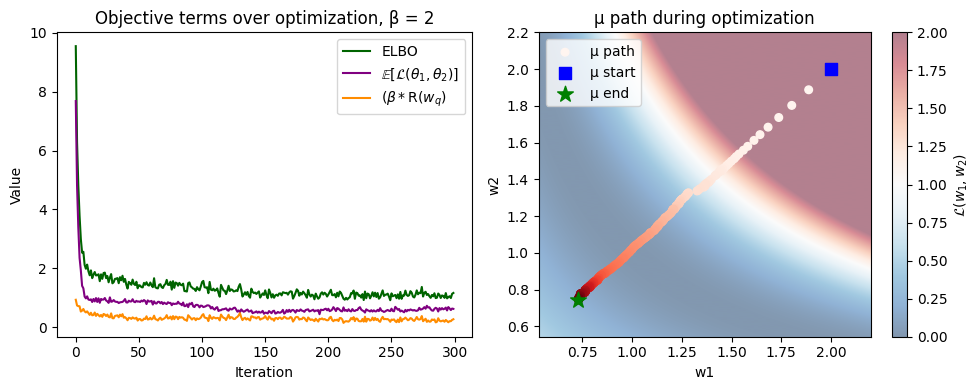

In [5]:
import numpy as np
import matplotlib.pyplot as plt

steps = np.arange(len(obj))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax0, ax1 = axes



#  ELBO components

ax0.plot(steps, obj, label='ELBO', c='darkgreen')
ax0.plot(steps, exp, label=r'$\mathbb{E}[\mathcal{L}(\theta_1,\theta_2)]$', c='purple')
ax0.plot(steps, kl, label=r'$(\beta*\mathrm{R}(w_q)$', c='darkorange')
ax0.set_xlabel('Iteration')
ax0.set_ylabel('Value')
ax0.set_title(f'Objective terms over optimization, β = {beta}')
ax0.legend()


# Panel 3: μ trajectory on loss landscape (ZOOMED OUT)

plt.sca(ax1)
pad = 0.2

# --- loss background FIRST 
plot_loss(loss_fct, [mu_history[:,0].min() - pad, mu_history[:,0].max()+pad], [mu_history[:,1].min()-pad, mu_history[:,1].max()+pad], alone='no', color='RdBu_r', title=None)

# --- μ trajectory 
n = mu_history.shape[0]
colors = np.linspace(0.2, 1.0, n)

ax1.scatter(mu_history[:,0], mu_history[:,1], c=colors, cmap='Reds', s=30, zorder=5, label='μ path')
ax1.scatter(mu_history[0,0], mu_history[0,1], c='blue', marker='s', s=70, zorder=6, label='μ start')
ax1.scatter(mu_history[-1,0], mu_history[-1,1], c='green', marker='*', s=140, zorder=7, label='μ end')


ax1.set_title('μ path during optimization')
ax1.legend()


plt.tight_layout()
plt.show()

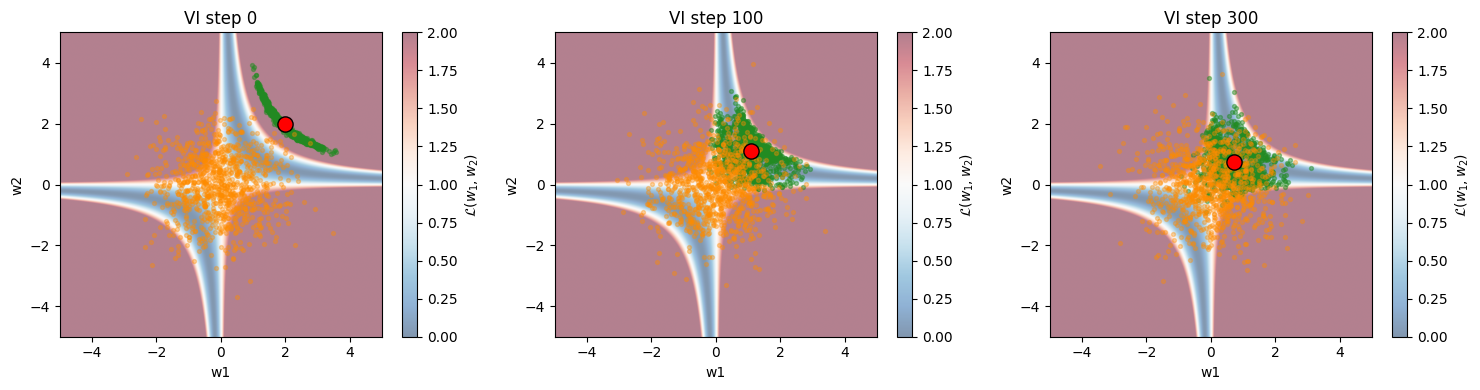

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def plot_vi_snapshot(ax, step, N_points=1000):
    mu_p = mu_history[step]
    points_q = sample_point_cloud(mu_p, N_points, N_BM_steps, BM_step_size, type='no drift')
    points_p = np.random.randn(N_points, 2)
    plt.sca(ax)
    plot_loss(loss_fct, [-5,5], [-5,5], alone='no', color='RdBu_r', title=f'VI step {step}')
    ax.scatter(*mu_p, c='red', s=120, edgecolors='black', zorder=10)
    ax.scatter(points_q[:,0], points_q[:,1], c='forestgreen', s=8, alpha=0.45)
    ax.scatter(points_p[:,0], points_p[:,1], c='darkorange', s=8, alpha=0.35)

steps_to_plot = [0, 100, len(mu_history)-1]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, step in zip(axes, steps_to_plot): plot_vi_snapshot(ax, step)
plt.tight_layout()
plt.show()


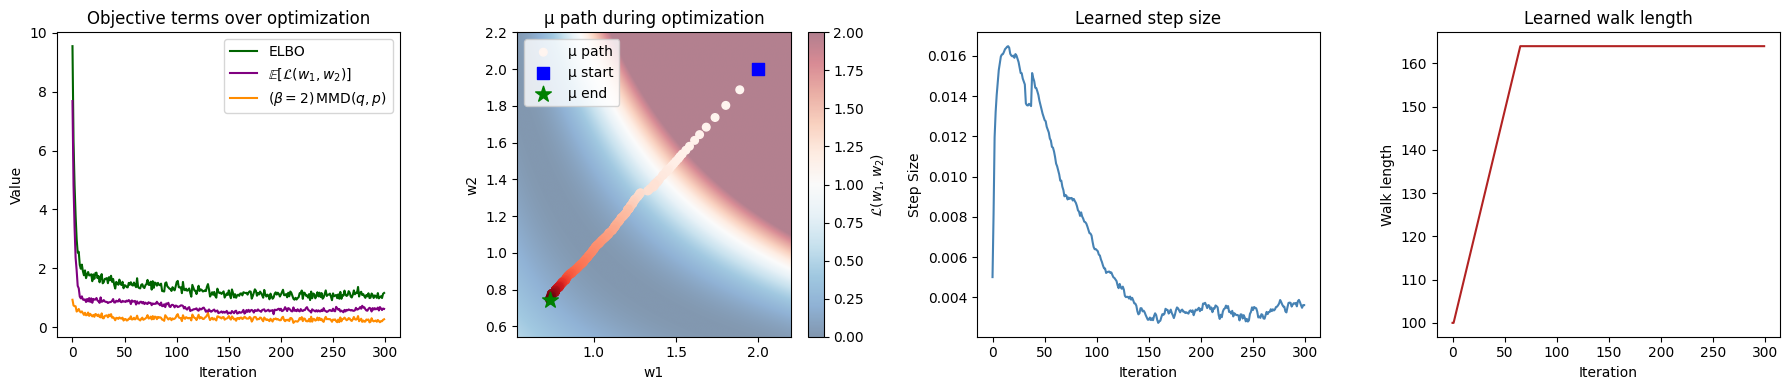

In [7]:
import numpy as np
import matplotlib.pyplot as plt

steps = np.arange(len(obj))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

ax0, ax1, ax2, ax3 = axes


# Panel 1: ELBO components

ax0.plot(steps, obj, label='ELBO', c='darkgreen')
ax0.plot(steps, exp, label=r'$\mathbb{E}[\mathcal{L}(w_1,w_2)]$', c='purple')
ax0.plot(steps, kl, label=r'$(\beta=2)\,\mathrm{MMD}(q,p)$', c='darkorange')
ax0.set_xlabel('Iteration')
ax0.set_ylabel('Value')
ax0.set_title('Objective terms over optimization')
ax0.legend()


# Panel 2: Mu trajectory

plt.sca(ax1)
pad = 0.2

# --- loss background FIRST ---
plot_loss(loss_fct, [mu_history[:,0].min() - pad, mu_history[:,0].max()+pad], [mu_history[:,1].min()-pad, mu_history[:,1].max()+pad], alone='no', color='RdBu_r', title=None)

# --- μ trajectory ---
n = mu_history.shape[0]
colors = np.linspace(0.2, 1.0, n)

ax1.scatter(mu_history[:,0], mu_history[:,1], c=colors, cmap='Reds', s=30, zorder=5, label='μ path')
ax1.scatter(mu_history[0,0], mu_history[0,1], c='blue', marker='s', s=70, zorder=6, label='μ start')
ax1.scatter(mu_history[-1,0], mu_history[-1,1], c='green', marker='*', s=140, zorder=7, label='μ end')

ax1.set_title('μ path during optimization')
ax1.legend()


ax2.plot(steps, dt, c='steelblue')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Step Size')
ax2.set_title('Learned step size')


ax3.plot(steps, T, c='firebrick')
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Walk length')
ax3.set_title('Learned walk length')


plt.tight_layout()
plt.show()